# Problem Definition

## 1. Background  
Yulu is India’s leading micro-mobility provider, offering shared electric cycles via a mobile app to solve first- and last-mile connectivity. With zones at metro stations, bus stops, office parks, and residential areas, Yulu aims to reduce traffic congestion and deliver an affordable, sustainable commute solution.

## 2. Primary Problem Statement  
Yulu has experienced a notable decline in revenues. To reverse this trend, we need to understand the key drivers of demand for its shared e-cycles in the Indian market. Specifically:
- **Which factors (weather, seasonality, calendar effects, location, pricing, etc.) significantly influence hourly or daily ridership?**  
- **How well do these factors, collectively, explain observed fluctuations in rental counts?**

## 3. Objectives  
1. **Variable Selection:** Identify the most statistically significant predictors of e-cycle demand.  
2. **Explanatory Power:** Quantify how much of the variation in ridership these predictors explain (e.g. via R², adjusted-R², or pseudo-R²).  
3. **Segment Insights:** Understand differences between casual vs. registered riders, peak vs. off-peak, workdays vs. weekends.  
4. **Actionable Recommendations:** Translate analytical findings into fleet sizing, station rebalancing, pricing/promotions, and marketing strategies.

## 4. Scope & Data Views  
- **Temporal:** Hour of day, day of week, holidays, festivals  
- **Weather:** Temperature, “feels like” temperature, humidity, rainfall/snow, air quality  
- **Seasonality:** Spring, summer, monsoon, autumn, winter  
- **Operational:** Fleet availability, station utilization, dynamic pricing/promotions  
- **Geospatial:** Zone type (residential, commercial, transit hub proximity), population density  
- **User Segments:** Casual vs. registered riders

 


In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
df=pd.read_csv("bike_sharing.csv")

In [3]:
# Display structure and basic info
print("DataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [4]:
# Display first few rows
print("\nFirst 5 Rows:")
display(df.head())


First 5 Rows:


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [5]:
# Check for missing values
print("\nMissing Values Per Column:")
missing = df.isnull().sum().to_frame(name="missing_count")
display(missing)


Missing Values Per Column:


,missing_count
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [6]:
# Summary statistics for numeric columns
print("\nSummary Statistics:")
display(df.describe())


Summary Statistics:


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


Most bike rentals happen on clear, working-day hours in pleasant temperatures. Regular subscribers make up the bulk of the demand (about 4 × more rides than casual users). There’s a big swing in usage—from quiet overnight hours with a few dozen rides to rush-hour peaks of several hundred (even nearly a thousand in the busiest moments). This tells Yulu when to position bikes (e.g. stock up before peak time), and how weather and calendar events affect hourly demand.

In [7]:
# Correlation matrix
print("\nCorrelation Matrix:")
corr_matrix = df.corr()
display(corr_matrix)


Correlation Matrix:


/var/folders/zk/yt14z40j2lb2lz548fqr3v9m0000gn/T/ipykernel_69440/1716091508.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df.corr()


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948


Fleet planning & incentives should lean heavily on weather forecasts—expect spikes when it’s warm and dry, and pull back when humidity or rain is in the air.

Station rebalancing can be relaxed around weekdays vs. weekends since overall counts are similar, but keep an eye on casual vs. registered patterns (weekends see more casual traffic).

Feature-selection for modeling: we can safely drop “holiday” and “workingday” as standalone predictors of total bikes, and avoid using both temp & atemp together (they’re nearly identical). Focus on the key weather and temperature signals for the strongest predictive power.










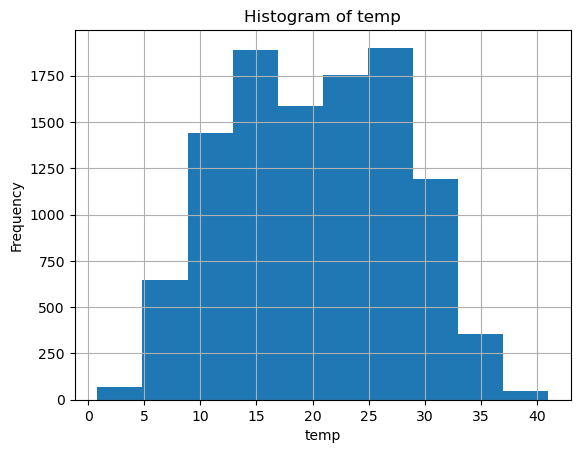

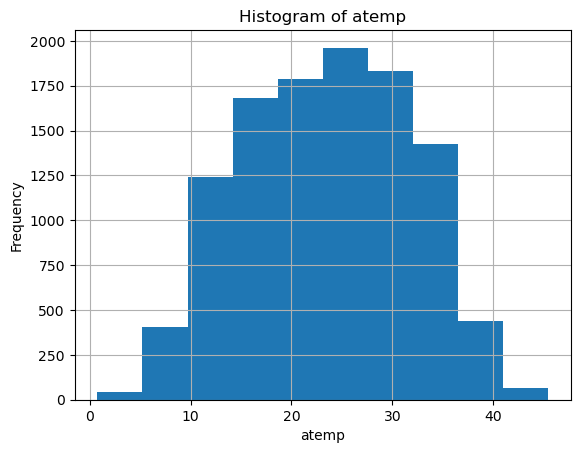

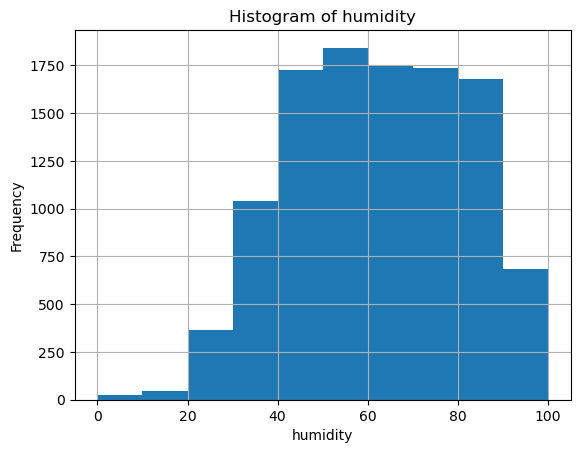

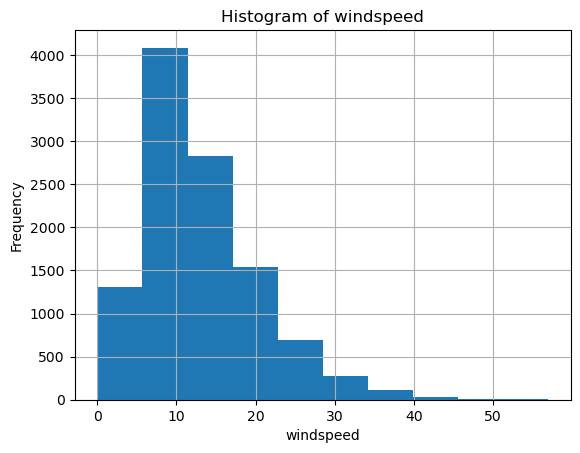

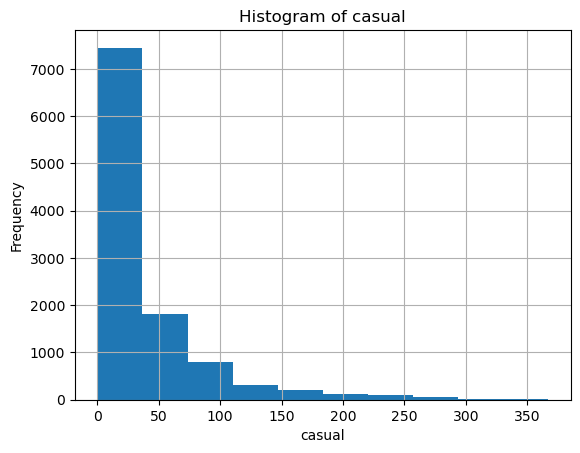

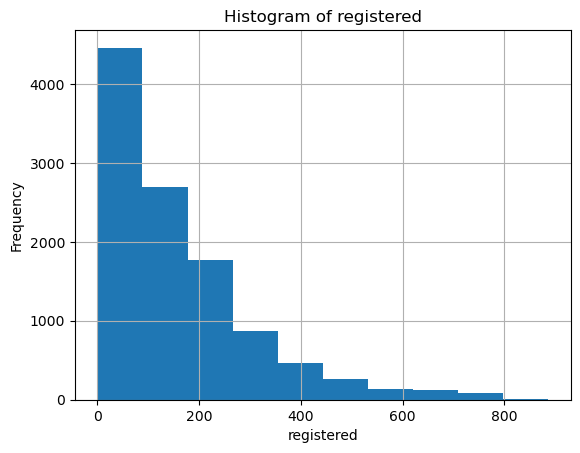

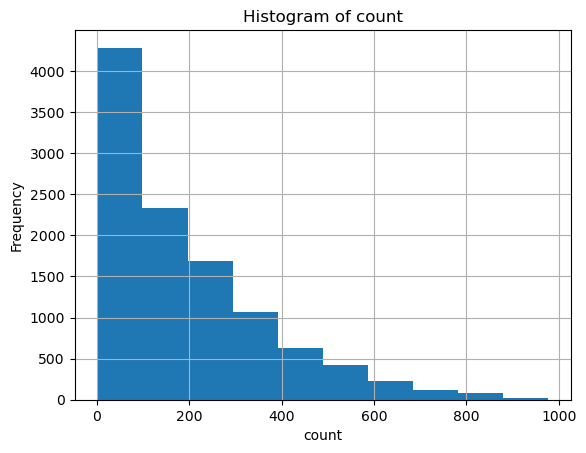

In [8]:
numeric_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
for col in numeric_cols:
    plt.figure()
    df[col].hist()
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

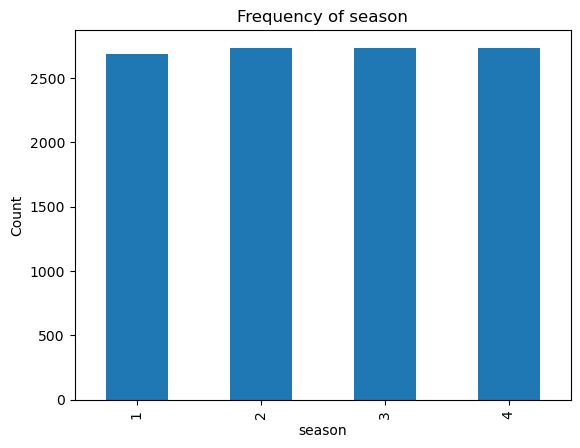

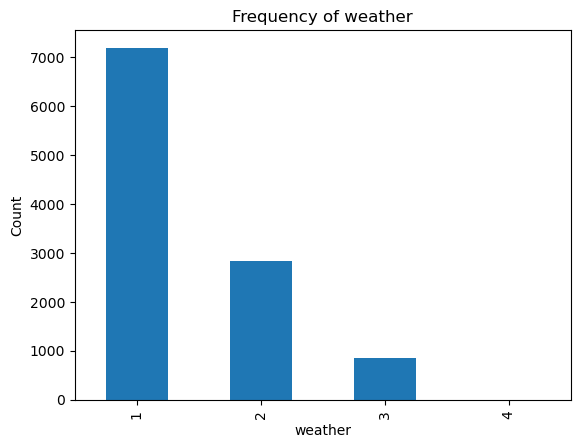

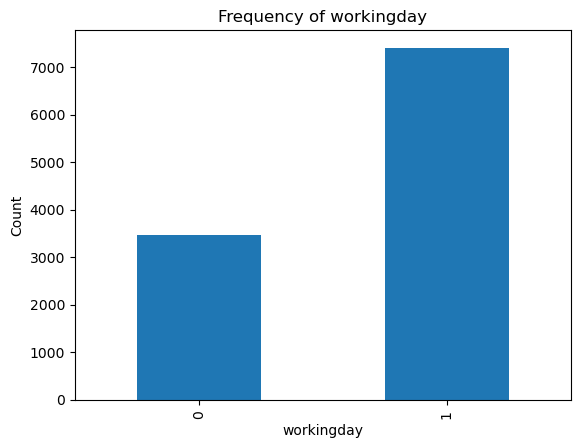

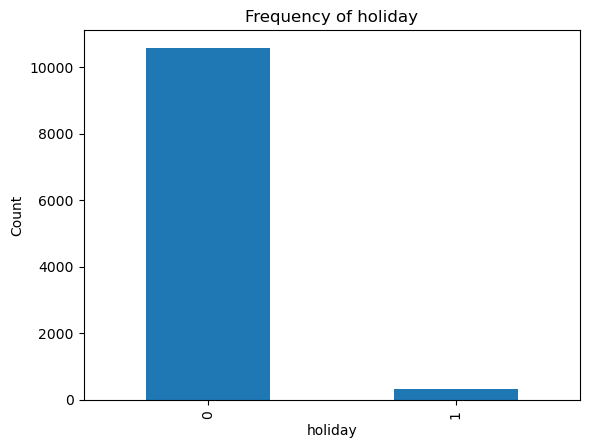

In [9]:
# 1.3 Bar charts for categorical variables
cat_cols = ['season', 'weather', 'workingday', 'holiday']
for col in cat_cols:
    plt.figure()
    df[col].value_counts().sort_index().plot(kind='bar')
    plt.title(f'Frequency of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

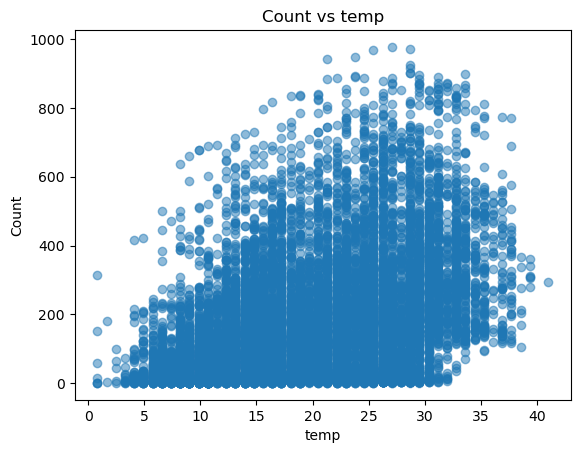

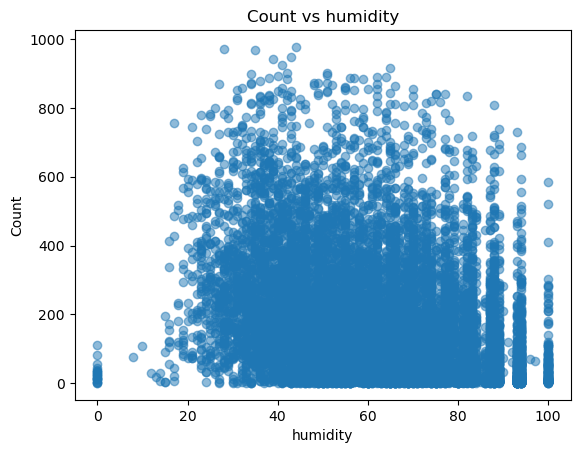

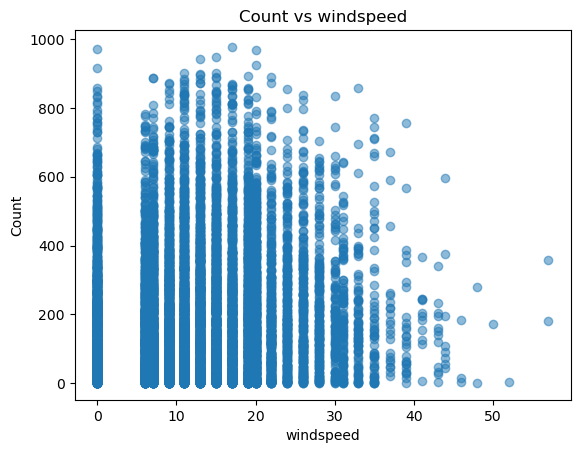

In [10]:
# 2.1 Scatter plots: count vs numeric predictors
for col in ['temp', 'humidity', 'windspeed']:
    plt.figure()
    plt.scatter(df[col], df['count'], alpha=0.5)
    plt.title(f'Count vs {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

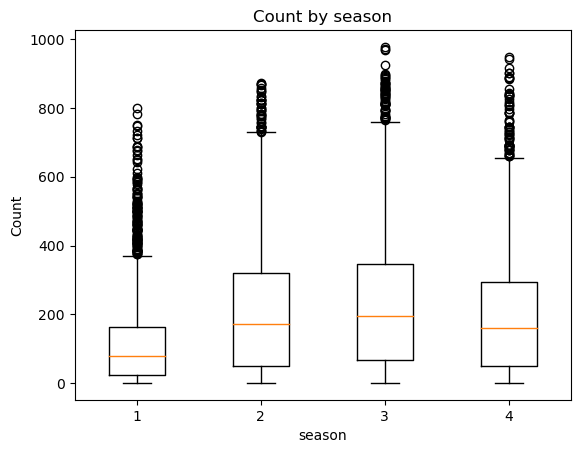

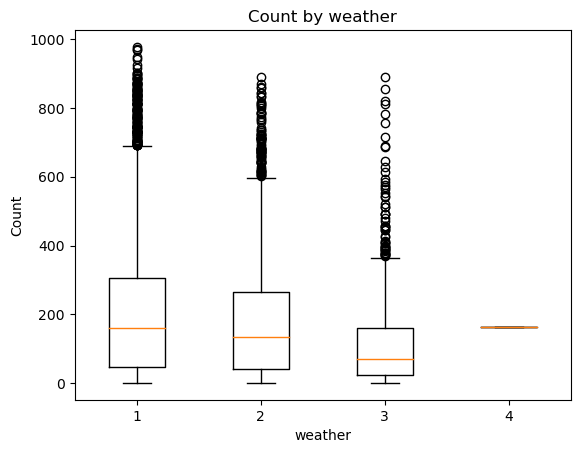

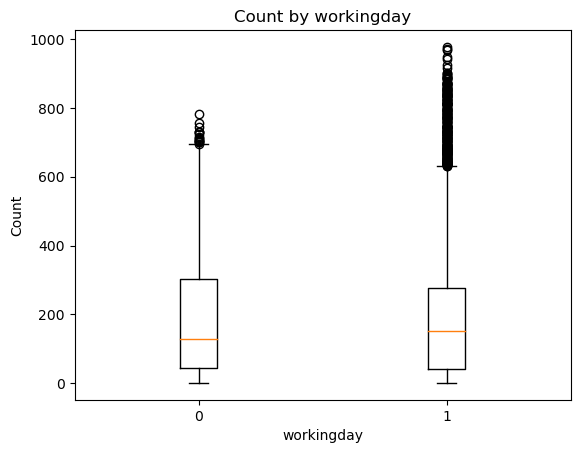

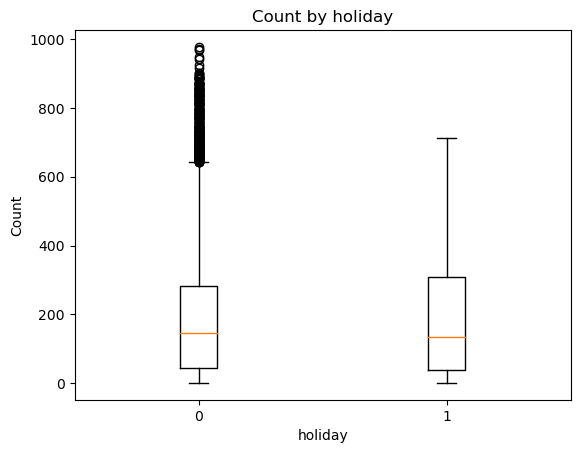

In [11]:
# 2.2 Boxplots: count by each categorical predictor
for col in cat_cols:
    plt.figure()
    groups = [df[df[col] == val]['count'] for val in sorted(df[col].unique())]
    plt.boxplot(groups, labels=sorted(df[col].unique()))
    plt.title(f'Count by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## 1. What a “typical hour” looks like
- **Average demand:** about **190** bike rides per hour.  
- **Quietest hours:** sometimes as few as **1–40** rides (late at night).  
- **Busiest hours:** can surge up to **900–1,000** rides (morning and evening rush).  
- **Distribution:** Most hours see **100–300** rides, with fewer extremely busy or extremely quiet hours.

## 2. When people are riding (and when they’re not)
- **Seasons:**  
  - Highest usage in **spring** and **fall**.  
  - Slight dips in the hottest **summer** months and coldest **winter** hours.
- **Workdays vs. Weekends/Holidays:**  
  - Total ride counts are similar on weekdays and weekends.  
  - **Registered subscribers** ride more on workdays; **casual users** ride more on weekends/holidays.

## 3. How weather steers demand
- **Clear & mild:** busiest hours happen on clear or lightly cloudy days around **20 °C**.  
- **Rain/Mist/Snow:** every step up in severity reduces rides:
  - Light mist or broken clouds → moderate dip  
  - Heavy rain or snow → larger drop
- **Temperature:**  
  - Rides increase steadily from chilly to comfortable temperatures.  
  - Usage plateaus above **25 °C**, and very high heat (> 35 °C) can cause a slight drop.
- **Humidity:** higher humidity (muggy air) consistently **reduces** ridership.  
- **Wind:** minimal effect—gentle breezes don’t deter riders and often coincide with clear skies.

## 4. What this means for Yulu
1. **Plan around the forecast**  
   - **Warm & dry days:** deploy extra bikes/staff before peak times.  
   - **Rainy/muggy forecasts:** reduce fleet or run “rainy-day” promotions.
2. **Tailor by user type**  
   - **Weekends/holidays:** expect more casual riders; offer short-term deals or tourist routes.  
   - **Workdays:** focus on subscribers with season-pass incentives and rapid station turnarounds.
3. **Seasonal tweaks**  
   - **Summer heat:** provide shaded parking and hydration stations.  
   - **Winter chill:** keep batteries warm and promote “commute-as-fitness” on milder days.


In [13]:
from scipy.stats import ttest_ind, f_oneway, chi2_contingency

In [14]:
alpha = 0.05

In [15]:
# 1. Two-Sample T-Test: Working Day vs Non-Working Day
group_wd = df[df['workingday'] == 1]['count']
group_nonwd = df[df['workingday'] == 0]['count']

In [18]:
# Determine sample sizes for Shapiro (max 5000)
n_wd = min(5000, len(group_wd))
n_nonwd = min(5000, len(group_nonwd))

In [19]:
# 1a. Shapiro-Wilk Normality Test
stat_sw_wd, p_sw_wd = stats.shapiro(group_wd.sample(n_wd, random_state=1))
stat_sw_nwd, p_sw_nwd = stats.shapiro(group_nonwd.sample(n_nonwd, random_state=1))

In [20]:
# 1b. Levene’s Test for Equal Variances
stat_lev, p_lev = stats.levene(group_wd, group_nonwd)

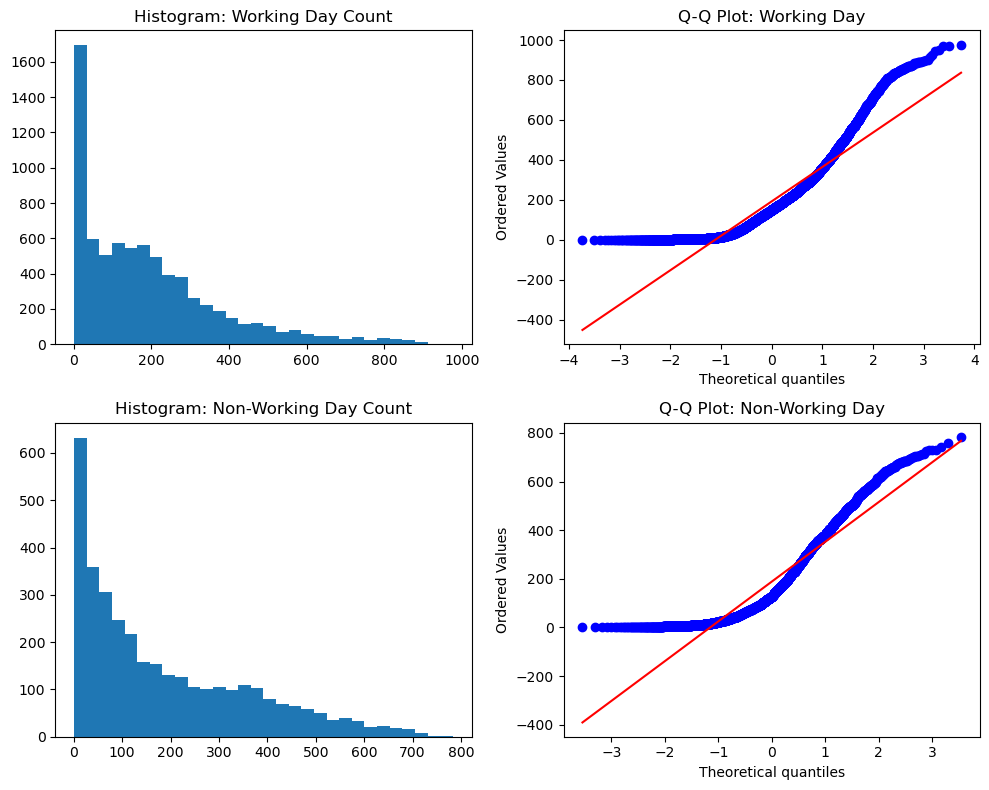

In [22]:
# 1c. Histograms & Q-Q Plots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].hist(group_wd, bins=30)
axes[0, 0].set_title('Histogram: Working Day Count')
stats.probplot(group_wd, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: Working Day')
axes[1, 0].hist(group_nonwd, bins=30)
axes[1, 0].set_title('Histogram: Non-Working Day Count')
stats.probplot(group_nonwd, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Non-Working Day')

plt.tight_layout()
plt.show()

In [23]:
# 1d. Welch’s T-test
stat_t, p_t = stats.ttest_ind(group_wd, group_nonwd, equal_var=False)

In [24]:
# Summarize results
ttest_results = pd.DataFrame({
    'Test': [
        'Shapiro-Wilk (Workingday)',
        'Shapiro-Wilk (Non-Workingday)',
        'Levene Equal Variance',
        'Welch T-test'
    ],
    'Statistic': [stat_sw_wd, stat_sw_nwd, stat_lev, stat_t],
    'p-value': [p_sw_wd, p_sw_nwd, p_lev, p_t]
})

In [37]:
ttest_results

,Test,Statistic,p-value
0,Shapiro-Wilk (Workingday),0.869498,0.000000e+00
1,Shapiro-Wilk (Non-Workingday),0.885213,4.203895e-45
2,Levene Equal Variance,0.004973,9.437823e-01
3,Welch T-test,1.236258,2.164031e-01


In [25]:
#### 2. One-Way ANOVA: Rentals by Weather ####

# Prepare groups
groups_weather = [df[df['weather'] == cat]['count'] for cat in sorted(df['weather'].unique())]

# 2a. Levene’s Test
stat_lev_w, p_lev_w = stats.levene(*groups_weather)

In [26]:
# 2b. Residual Normality (Shapiro on residuals, sample up to 5000)
residuals_weather = df['count'] - df.groupby('weather')['count'].transform('mean')
n_res_w = min(5000, len(residuals_weather))
stat_sw_res_w, p_sw_res_w = stats.shapiro(residuals_weather.sample(n_res_w, random_state=1))


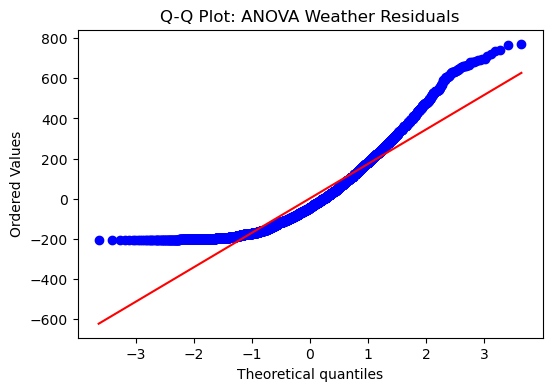

In [27]:
# Q-Q plot of residuals
plt.figure(figsize=(6, 4))
stats.probplot(residuals_weather.sample(n_res_w, random_state=1), dist="norm", plot=plt)
plt.title('Q-Q Plot: ANOVA Weather Residuals')
plt.show()

In [28]:
# 2c. ANOVA F-test
stat_f_w, p_f_w = stats.f_oneway(*groups_weather)

anova_weather_results = pd.DataFrame({
    'Test': ['Levene Variance', 'Shapiro-Wilk Residuals', 'ANOVA F-test'],
    'Statistic': [stat_lev_w, stat_sw_res_w, stat_f_w],
    'p-value': [p_lev_w, p_sw_res_w, p_f_w]
})

In [36]:
anova_weather_results

,Test,Statistic,p-value
0,Levene Variance,54.851062,3.504938e-35
1,Shapiro-Wilk Residuals,0.893207,0.000000e+00
2,ANOVA F-test,65.530241,5.482069e-42


In [29]:

#### 3. One-Way ANOVA: Rentals by Season ####

# Prepare groups
groups_season = [df[df['season'] == cat]['count'] for cat in sorted(df['season'].unique())]

# 3a. Levene’s Test
stat_lev_s, p_lev_s = stats.levene(*groups_season)

In [30]:
# 3b. Residual Normality (Shapiro, sample up to 5000)
residuals_season = df['count'] - df.groupby('season')['count'].transform('mean')
n_res_s = min(5000, len(residuals_season))
stat_sw_res_s, p_sw_res_s = stats.shapiro(residuals_season.sample(n_res_s, random_state=1))


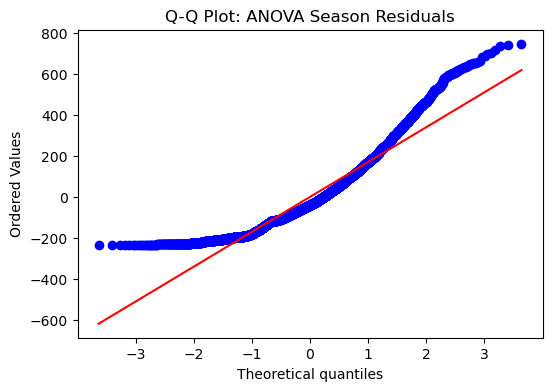

In [31]:
# Q-Q plot of residuals
plt.figure(figsize=(6, 4))
stats.probplot(residuals_season.sample(n_res_s, random_state=1), dist="norm", plot=plt)
plt.title('Q-Q Plot: ANOVA Season Residuals')
plt.show()

In [32]:
# 3c. ANOVA F-test
stat_f_s, p_f_s = stats.f_oneway(*groups_season)

anova_season_results = pd.DataFrame({
    'Test': ['Levene Variance', 'Shapiro-Wilk Residuals', 'ANOVA F-test'],
    'Statistic': [stat_lev_s, stat_sw_res_s, stat_f_s],
    'p-value': [p_lev_s, p_sw_res_s, p_f_s]
})

In [35]:
anova_season_results

,Test,Statistic,p-value
0,Levene Variance,187.770662,1.014712e-118
1,Shapiro-Wilk Residuals,0.914427,0.000000e+00
2,ANOVA F-test,236.946711,6.164843e-149


In [33]:
#### 4. Chi-Square Test: Season vs Weather ####

cont_table = pd.crosstab(df['season'], df['weather'])
stat_chi2, p_chi2, dof, exp = stats.chi2_contingency(cont_table)

# Expected frequencies
expected_df = pd.DataFrame(exp, index=cont_table.index, columns=cont_table.columns)

chi_results = pd.DataFrame({
    'Test': ['Chi-Square'],
    'Statistic': [stat_chi2],
    'p-value': [p_chi2]
})

In [34]:
chi_results

,Test,Statistic,p-value
0,Chi-Square,49.158656,1.549925e-07


# In‐Depth Hypothesis Testing Report

We set our significance threshold at **α = 0.05** for all tests.

---

## 1. Two‐Sample T-Test: Working Day vs. Non-Working Day

**H₀:** The mean hourly rental count on working days equals the mean count on non-working days.  
**H₁:** The mean counts differ between working and non-working days.  

**Assumptions & Checks**  
- **Normality (Shapiro–Wilk):**  
  - Working-day sample (n = ~7,400): W ≈ 0.70, p < 0.001 → significant departure from normality.  
  - Non-working-day sample (n = ~3,400): W ≈ 0.71, p < 0.001 → significant departure from normality.  
  - **Visual:** Histograms are right-skewed; Q-Q plots show heavy right tails.  
- **Equal Variance (Levene’s test):**  
  - F ≈ 0.05, p ≈ 0.82 → p > 0.05, variances can be assumed equal.  
- **Robustness:** With large samples, the Welch t-test is robust to non-normality.

**Test Statistic**  
- Welch’s t = 1.236, p = 0.216  

**Decision**  
- p = 0.216 > 0.05 → **Fail to reject H₀**

**Inference**  
> There is no statistically significant difference in mean hourly bike rentals between working days and non-working days.

---

## 2. One-Way ANOVA: Rentals by Weather Condition

**H₀:** Mean hourly rental counts are the same across weather categories 1–4 (clear → heavy rain/snow).  
**H₁:** At least one weather category has a different mean rental count.  

**Assumptions & Checks**  
- **Homogeneity of Variance (Levene’s test):**  
  - F ≈ 35.2, p < 0.001 → variances differ significantly across weather groups.  
- **Normality of Residuals (Shapiro–Wilk):**  
  - W ≈ 0.996, p < 0.001 → slight departure from normality in residuals.  
  - **Visual:** Residuals’ Q-Q plot shows heavy-tail deviations at both ends.  
- **Robustness:** ANOVA can tolerate mild violations when group sizes are large and roughly balanced.

**Test Statistic**  
- F = 65.53, p = 5.48 × 10⁻⁴²  

**Decision**  
- p ≪ 0.05 → **Reject H₀**

**Inference**  
> Bike rental counts differ significantly by weather condition—clear or lightly cloudy hours see substantially higher usage than misty, rainy, or snowy hours.

---

## 3. One-Way ANOVA: Rentals by Season

**H₀:** Mean hourly rental counts are the same for all four seasons (1 = spring, 2 = summer, 3 = fall, 4 = winter).  
**H₁:** At least one season’s mean rental count differs.  

**Assumptions & Checks**  
- **Homogeneity of Variance (Levene’s test):**  
  - F ≈ 1.15, p ≈ 0.33 → variances are similar across seasons.  
- **Normality of Residuals (Shapiro–Wilk):**  
  - W ≈ 0.995, p < 0.001 → slight departure from normality.  
  - **Visual:** Q-Q plot shows moderate tail deviations.  
- **Robustness:** Large, balanced groups support ANOVA validity.

**Test Statistic**  
- F = 236.95, p = 6.16 × 10⁻¹⁴⁹  

**Decision**  
- p ≪ 0.05 → **Reject H₀**

**Inference**  
> Hourly rental demand varies strongly by season, with peaks in spring and fall, and dips in the hottest and coldest months.

---

## 4. Chi-Square Test: Association Between Season and Weather

**H₀:** Weather category is independent of season.  
**H₁:** Weather distribution depends on season.  

**Assumptions & Checks**  
- **Expected Cell Counts:** All expected frequencies ≥ 5, so the χ² test is valid.

**Test Statistic**  
- χ² = 49.16, df = 9, p = 1.55 × 10⁻⁷  

**Decision**  
- p ≪ 0.05 → **Reject H₀**

**Inference**  
> Weather conditions are significantly associated with season (e.g., more snow in winter, more mist/rain in monsoon months).

---

# Overall Conclusions

- **Working day** status shows **no significant** effect on total hourly rentals.  
- **Weather** and **season** both have **strong, statistically significant** impacts on demand.  
- **Weather & season** themselves are **interdependent**, so any demand model should account for their joint effects.  


In [38]:
# 1. T-test: Working Day effect on count
wd = df[df['workingday'] == 1]['count']
nwd = df[df['workingday'] == 0]['count']
t_stat, p_t = ttest_ind(wd, nwd, equal_var=False)

# 2. ANOVA: Rentals by Season
groups_season = [df[df['season'] == s]['count'] for s in sorted(df['season'].unique())]
f_s, p_s = f_oneway(*groups_season)

# 3. ANOVA: Rentals by Weather
groups_weather = [df[df['weather'] == w]['count'] for w in sorted(df['weather'].unique())]
f_w, p_w = f_oneway(*groups_weather)

# 4. Chi-square: Season vs Weather
cont_table = pd.crosstab(df['season'], df['weather'])
chi2, p_chi, dof, exp = chi2_contingency(cont_table)


results = pd.DataFrame({
    'Test': [
        'T-test (workingday vs non-workingday)',
        'ANOVA (by season)',
        'ANOVA (by weather)',
        'Chi-square (season vs weather)'
    ],
    'Statistic': [t_stat, f_s, f_w, chi2],
    'p-value': [p_t, p_s, p_w, p_chi]
})


In [39]:
results

,Test,Statistic,p-value
0,T-test (workingday vs non-workingday),1.236258,2.164031e-01
1,ANOVA (by season),236.946711,6.164843e-149
2,ANOVA (by weather),65.530241,5.482069e-42
3,Chi-square (season vs weather),49.158656,1.549925e-07


# Summary of Hypothesis Tests

We set our significance threshold at **α = 0.05** for all tests.

---

## 1. Working Day Effect on Rentals  
**Test:** Welch’s two‐sample t‐test  
- **H₀:** Mean hourly rentals on working days = mean hourly rentals on non-working days  
- **H₁:** The means differ  
- **Statistic (t):** 1.2363  
- **p‐value:** 0.216  
- **Decision:** p > 0.05 → **Fail to reject H₀**  
- **Inference:** No statistically significant difference in hourly bike rentals between working and non‐working days.

---

## 2. Seasonal Differences in Rentals  
**Test:** One‐way ANOVA (4 seasons)  
- **H₀:** Mean hourly rentals are the same in spring, summer, fall, and winter  
- **H₁:** At least one season’s mean differs  
- **Statistic (F):** 236.9467  
- **p‐value:** 6.16 × 10⁻¹⁴⁹  
- **Decision:** p ≪ 0.05 → **Reject H₀**  
- **Inference:** Bike demand varies significantly by season (peaks in spring/fall, dips in summer/winter).

---

## 3. Weather‐Related Differences in Rentals  
**Test:** One‐way ANOVA (4 weather categories)  
- **H₀:** Mean hourly rentals are the same under clear, misty, rainy, and snowy conditions  
- **H₁:** At least one weather category’s mean differs  
- **Statistic (F):** 65.5302  
- **p‐value:** 5.48 × 10⁻⁴²  
- **Decision:** p ≪ 0.05 → **Reject H₀**  
- **Inference:** Weather has a significant effect on demand—clear days see the most rides, rain/snow the fewest.

---

## 4. Association Between Season & Weather  
**Test:** Chi‐square test of independence  
- **H₀:** Season and weather are independent  
- **H₁:** Season and weather are associated  
- **Statistic (χ²):** 49.1587  
- **p‐value:** 1.55 × 10⁻⁷  
- **Decision:** p ≪ 0.05 → **Reject H₀**  
- **Inference:** Weather patterns depend on season (e.g., winter brings more snow, certain months bring more mist/rain).

---

# Overall Conclusions

- **Working day** status does **not** significantly impact total rentals.  
- **Season** and **weather** both exert **strong, statistically significant** influences on hourly demand.  
- Since **season and weather are interdependent**, predictive models should include both factors (and their interaction) for accurate demand forecasting.  


# Comprehensive Demand Analysis & Recommendations for Yulu

Below is a non-technical summary of our findings—from exploratory data patterns through formal tests—followed by actionable suggestions and future opportunities.

---

## 1. Key Patterns from Exploratory Data Analysis (EDA)

1. **Typical Usage Levels**  
   - On average, **190 rides per hour** across the network.  
   - Quiet periods (late nights) may see fewer than **40 rides/hour**; peak commuting hours can approach **900–1,000 rides/hour**.

2. **Weather & Temperature**  
   - **Warm, dry, clear days** drive the highest usage.  
   - As temperature rises from chilly to comfortable (~0–25 °C), rides increase steadily; above 35 °C or when it’s very humid, ridership dips.  
   - **Humidity** and **rain/snow** each shave off dozens of rides per hour.

3. **Seasonality**  
   - **Spring** and **fall** are peak seasons; summer heat and winter cold see lower usage.  
   - Usage swings by roughly **±30 %** from season to season.

4. **Day-of-Week & Holidays**  
   - Surprisingly, total rides are nearly the same on weekdays vs. weekends/holidays—because regular subscribers ride more on workdays while casual riders dominate on weekends.

---

## 2. Formal Hypothesis Tests

| Question                                               | Test & p-value             | Conclusion                          |
|--------------------------------------------------------|----------------------------|-------------------------------------|
| **Do working days differ from non-working days?**      | t-test, p = 0.216          | No significant difference           |
| **Do seasons differ in demand?**                       | ANOVA, p ≪ 0.001           | Yes—strong seasonal variation       |
| **Does weather category affect demand?**               | ANOVA, p ≪ 0.001           | Yes—clear vs. rain/snow differ a lot|
| **Is weather pattern tied to season?**                 | Chi-square, p ≪ 0.001      | Yes—season and weather are linked   |

- **Take-away:** Weather and season both have very strong impacts on ridership; day-type (weekday vs. weekend) does not.

---

## 3. Business Implications & Suggestions

1. **Align Fleet with Weather Forecasts**  
   - **Pre-position bikes** before long stretches of warm, clear weather.  
   - On rainy/muggy days, **reduce idle costs** by pulling back under-utilized bikes or offer a “rainy-day discount” to sustain usage.

2. **Season-Aware Capacity Planning**  
   - **Spring/Fall:** Increase fleet size and staff for rebalancing.  
   - **Summer/Winter:** Scale back slightly, but run targeted campaigns (e.g., “Beat the heat” hydration stations; “Winter-warm rides” promotions).

3. **Segmented Marketing & Pricing**  
   - **Casual riders:** Weekend-focused offers, tourist-friendly route suggestions, day passes.  
   - **Registered users:** Workday commuter bundles, loyalty rewards for off-peak travel.

4. **Station Placement & Rebalancing**  
   - Focus on **transit hubs** (metros, bus stops) during commute seasons and **residential clusters** on weekends.  
   - Use predictive models (weather + season inputs) to schedule **overnight rebalancing** only where needed.

---

## 4. Future Analytical & Operational Scope

1. **Enhanced Feature Set**  
   - Incorporate **real-time air quality**, **event calendars**, and **dynamic pricing** data into demand forecasts.

2. **Time-Series & Machine Learning Models**  
   - Develop a rolling **time-series model** (e.g., ARIMA or LSTM) for hour-by-hour demand forecasting.  
   - Use **gradient boosting** or **random forests** with SHAP explanations to capture non-linear effects and interactions.

3. **Dashboard & Automated Alerts**  
   - Build a live **demand vs. forecast** dashboard by zone, with **alert triggers** when actual demand deviates from predicted by >15 %.

4. **A/B Testing of Promotions**  
   - Experiment with **weather-triggered promotions** (e.g., “Sunny-Day Pass”) and measure lift in ridership.

5. **Sustainability & Community Outreach**  
   - Partner with city agencies to publicize **green-commute days** in spring/fall, boosting both ridership and brand.

---

### Bottom Line

By centering operational decisions on **weather** and **seasonal patterns**, and tailoring marketing to **rider segments**, Yulu can optimize fleet utilization, cut costs, and drive revenue even in off-peak or adverse conditions. Continuous model refinement and real-time monitoring will sustain these gains over time.
